In [2]:
import umap
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from zadu import zadu
import torch
from pcc import PCC, PCUMAP
from pcc.metrics import Metrics
from msi_atlas.annotations import get_annotations
from pcc.metrics import Metrics
from sklearn.cluster import KMeans
import torch
from torchdr import UMAP
from msi_visual.utils import normalize
from importlib import reload
from PIL import Image
from pcc import PCC
import cv2
import torch


class MSIDRWrapper:
    def __init__(self, dr_method):
        self.dr_method = dr_method
    
    def __call__(self, X):
        h, w = X.shape[:2]
        mask = X.sum(axis=-1) > 0
        
        # Only process non-zero pixels
        X_masked = X[mask]
        reduced_masked = self.dr_method.fit_transform(X_masked)
        
        # Initialize result array
        result = np.zeros((h * w, reduced_masked.shape[1]))
        
        # Put reduced values back in original positions
        result[mask.flatten()] = reduced_masked
        
        # Reshape back to image dimensions
        result = np.reshape(result, (h, w, -1))
        result = np.uint8(255 * normalize(result, 0, 100))
        result[mask == 0] = 0
        return result


methods = ["PCUMAP", "PCC", "PCA", "UMAP", "TSNE", "dtne", "localmap", "pacmap", "trimap", "phate"]
def get_reducer(name, random_state=42):
    if name == "PCUMAP":
        return PCUMAP(n_components=3, device='cuda', sampling="random", epoch_to_start_correlation_loss=10, num_points=1000, random_state=random_state)
    elif name == "PCC":
        return PCC(n_components=3, num_epochs=1000, num_points=1000, pearson=True, spearman=False, beta=20, k_epoch=50, temperature=20, batch_size=4096*2*2, sampling="random", linear_cluster_weight=1.0, cluster=True, random_state=random_state)
    elif name == "PCA":
        return PCA(n_components=3)
    elif name == "UMAP":
        return UMAP(n_components=3)
    elif name == "TSNE":
        return TSNE(n_components=3)
    elif name == "dtne":
        from dtne import DTNE
        return DTNE(n_components=3, k_neighbors=10, l=2, random_state=random_state)
    elif name == "localmap":
        from pacmap import LocalMAP
        return LocalMAP(n_components=3, n_neighbors=10, MN_ratio=0.5, FP_ratio=2.0, random_state=random_state)
    elif name == "pacmap":
        from pacmap import PaCMAP
        return PaCMAP(n_components=3, random_state=random_state)
    elif name == "trimap":
        import trimap
        return trimap.TRIMAP(n_components=3, random_state=random_state)
    
    elif name == "phate":
        import phate
        return phate.PHATE(n_components=3, random_state=random_state)


def equalize_hist(viz):
    return cv2.merge([cv2.equalizeHist(c) for c in cv2.split(viz)])

def get_msi_metrics(X, viz, mouse_index, category_keys=["main_cat1", "Allen_name", "sub_cat2"]):
    polygons, categories = get_annotations("/home/jacob/Desktop/msi-atlas/NRL4485-s2_annotations-only-updatedV2_of-V20.json", mouse_index, category_keys=category_keys)

    # Remove background polygons and categories
    non_bg_mask = [cat != "BG" for cat in categories]
    polygons = [poly for poly, keep in zip(polygons, non_bg_mask) if keep]
    categories = [cat for cat, keep in zip(categories, non_bg_mask) if keep]

    # Draw polygons over the visualization
    viz_with_annotations = viz.copy()
    mask = np.zeros(viz_with_annotations.shape[:2], dtype=np.uint8)

    # Create label encoder and fit to categories
    label_encoder = LabelEncoder()
    categories = label_encoder.fit_transform(categories)
    colors = plt.cm.rainbow(np.linspace(0, 1, len(set(categories))))

    for polygon, category in zip(polygons, categories):
        category = int(category)
        # Convert polygon points to integer coordinates
        points = polygon.squeeze().astype(np.int32) // 2
        

        color = np.uint8(255 * colors[category])[:3]
        color = [int(c) for c in color]
        cv2.drawContours(viz_with_annotations, [points], -1, color=color, thickness=1, lineType=cv2.LINE_AA)
        cv2.drawContours(mask, [points], -1, color=category + 1, thickness=-1, lineType=cv2.LINE_AA)

    # display(Image.fromarray(viz))
    # display(Image.fromarray(viz_with_annotations))
    X_from_annotations = X[mask > 0]
    embeddings = viz[mask > 0]
    cluster_assignments = mask[mask > 0]


    metrics = Metrics(X_from_annotations, embeddings, cluster_assignments, sub_sample=10, n_clusters=[128], cluster_assignments={10: cluster_assignments}, label_local=True).compute_all_metrics()
    return metrics


/home/jacob/miniconda3/envs/dl/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
import numpy as np
from numba import njit, prange

@njit(parallel=True, fastmath=True)
def _update_dmin_cheb_early(X, ci, dmin):
    n, d = X.shape
    for i in prange(n):
        mx = 0.0
        # compute Chebyshev distance to ci with short-circuit
        for t in range(d):
            diff = X[i, t] - ci[t]
            if diff < 0: diff = -diff
            if diff > mx: mx = diff
            # early abandon: can't beat current dmin[i]
            if mx > dmin[i]:
                mx = dmin[i]  # clamp to avoid a branch later
                break
        # dmin = min(dmin, newdist)
        if mx < dmin[i]:
            dmin[i] = mx

@njit(parallel=True, fastmath=True)
def _cheb_dist_assign(X, C, labels, best):
    n, d = X.shape
    k = C.shape[0]
    # initialize best to +inf outside
    for j in range(k):
        cj = C[j]
        for i in prange(n):
            mx = 0.0
            for t in range(d):
                diff = X[i, t] - cj[t]
                if diff < 0: diff = -diff
                if diff > mx: mx = diff
                # early abandon when already worse than best[i]
                if mx > best[i]:
                    mx = best[i]
                    break
            if mx < best[i]:
                best[i] = mx
                labels[i] = j

def gonzalez_kcenter_cheb_numba(X, k, seed=0, dtype=np.float32):
    X = np.ascontiguousarray(X, dtype=dtype)
    n, d = X.shape
    rng = np.random.default_rng(seed)
    centers_idx = [int(rng.integers(n))]

    # init dmin with first center
    c0 = X[centers_idx[0]].copy()
    dmin = np.empty(n, dtype=dtype)
    # compute cheb to c0
    for i in range(n):
        mx = 0.0
        for t in range(d):
            diff = X[i, t] - c0[t]
            if diff < 0: diff = -diff
            if diff > mx: mx = diff
        dmin[i] = mx

    for _ in range(1, k):
        i = int(np.argmax(dmin))
        centers_idx.append(i)
        ci = X[i].copy()
        _update_dmin_cheb_early(X, ci, dmin)

    # assignment
    labels = np.zeros(n, dtype=np.int32)
    best = np.full(n, np.inf, dtype=dtype)
    C = X[np.array(centers_idx)]
    _cheb_dist_assign(X, C, labels, best)
    return labels


In [ ]:
import numpy as np
from numba import njit, prange

# ---------- metric kernels with early-abandon where possible ----------

@njit(parallel=True, fastmath=True)
def init_best_cheb(X, c, best):
    n, d = X.shape
    for i in prange(n):
        mx = 0.0
        for t in range(d):
            diff = X[i, t] - c[t]
            if diff < 0: diff = -diff
            if diff > mx: mx = diff
        best[i] = mx

@njit(parallel=True, fastmath=True)
def update_best_cheb(X, c, best, labels, new_label):
    n, d = X.shape
    for i in prange(n):
        mx = 0.0
        bd = best[i]
        for t in range(d):
            diff = X[i, t] - c[t]
            if diff < 0: diff = -diff
            if diff > mx: mx = diff
            # early abandon: cannot be < best[i] anymore
            if mx > bd:
                mx = bd
                break
        if mx < bd:
            best[i] = mx
            labels[i] = new_label

@njit(parallel=True, fastmath=True)
def init_best_l2(X, c, best):
    n, d = X.shape
    for i in prange(n):
        s = 0.0
        for t in range(d):
            diff = X[i, t] - c[t]
            s += diff*diff
        best[i] = np.sqrt(s)

@njit(parallel=True, fastmath=True)
def update_best_l2(X, c, best, labels, new_label):
    n, d = X.shape
    for i in prange(n):
        s = 0.0
        thr2 = best[i] * best[i]
        for t in range(d):
            diff = X[i, t] - c[t]
            s += diff*diff
            # early abandon if partial sum already exceeds best^2
            if s > thr2:
                s = thr2  # clamp
                break
        if s < thr2:
            dist = np.sqrt(s)
            best[i] = dist
            labels[i] = new_label

@njit(parallel=True, fastmath=True)
def init_best_l1(X, c, best):
    n, d = X.shape
    for i in prange(n):
        s = 0.0
        for t in range(d):
            diff = X[i, t] - c[t]
            if diff < 0: diff = -diff
            s += diff
        best[i] = s

@njit(parallel=True, fastmath=True)
def update_best_l1(X, c, best, labels, new_label):
    n, d = X.shape
    for i in prange(n):
        s = 0.0
        thr = best[i]
        for t in range(d):
            diff = X[i, t] - c[t]
            if diff < 0: diff = -diff
            s += diff
            if s > thr:  # early abandon once worse than current best
                s = thr
                break
        if s < thr:
            best[i] = s
            labels[i] = new_label

@njit(parallel=True, fastmath=True)
def init_best_angular(X, c, best):
    # X and c must be L2-normalized row-wise.
    n, d = X.shape
    for i in prange(n):
        dot = 0.0
        for t in range(d):
            dot += X[i, t] * c[t]
        if dot < -1.0: dot = -1.0
        if dot >  1.0: dot =  1.0
        best[i] = np.arccos(dot)

@njit(parallel=True, fastmath=True)
def update_best_angular(X, c, best, labels, new_label):
    n, d = X.shape
    for i in prange(n):
        dot = 0.0
        for t in range(d):
            dot += X[i, t] * c[t]
        if dot < -1.0: dot = -1.0
        if dot >  1.0: dot =  1.0
        dist = np.arccos(dot)
        if dist < best[i]:
            best[i] = dist
            labels[i] = new_label

# ---------- main wrapper: subset of k's, metric-pluggable, snapshots only when needed ----------

def gonzalez_subset_k_numba(
    X, ks, metric="chebyshev", seed=0, return_labels=True, dtype=np.float32, normalize_for_angular=False
):
    """
    Gonzalez (farthest-first) k-center for a subset of k's.
    Reuses distances incrementally and snapshots labels only for requested k's.

    Args:
        X: (n, d) array
        ks: iterable of k values (e.g., [3, 5, 10])
        metric: 'chebyshev' | 'euclidean' | 'manhattan' | 'angular'
        seed: RNG seed
        return_labels: if True, snapshot labels per requested k
        dtype: internal dtype (float32 recommended)
        normalize_for_angular: if True and metric='angular', row-normalize X inside this function

    Returns:
        centers_by_k: dict {k: np.ndarray of center indices (len=k)}
        labels_by_k:  dict {k: np.ndarray of labels (len=n)}   (only if return_labels=True)
    """
    X = np.ascontiguousarray(X, dtype=dtype)
    n, d = X.shape

    ks_sorted = sorted(set(int(k) for k in ks if k >= 1))
    if not ks_sorted:
        return ({}, {}) if return_labels else {}

    k_max = ks_sorted[-1]
    rng = np.random.default_rng(seed)

    if metric == "angular":
        if normalize_for_angular:
            # L2-normalize rows in-place (float32-safe)
            norms = np.linalg.norm(X, axis=1, keepdims=True)
            norms[norms == 0] = 1.0
            X = X / norms
        # else: assume caller already normalized each row

    # Pick first center
    c0 = int(rng.integers(n))
    centers = [c0]

    # best distance to nearest chosen center & labels
    best = np.empty(n, dtype=dtype)
    labels = np.zeros(n, dtype=np.int32)

    # Initialize best with first center
    if metric == "chebyshev":
        init_best_cheb(X, X[c0], best)
    elif metric == "euclidean":
        init_best_l2(X, X[c0], best)
    elif metric == "manhattan":
        init_best_l1(X, X[c0], best)
    elif metric == "angular":
        init_best_angular(X, X[c0], best)
    else:
        raise ValueError(f"Unsupported metric: {metric}")

    centers_by_k = {}
    labels_by_k = {} if return_labels else None
    if 1 in ks_sorted:
        centers_by_k[1] = np.array(centers, dtype=np.int64)
        if return_labels:
            labels_by_k[1] = labels.copy()

    # Grow to k_max, updating best distances with early-abandon kernels
    for cur_k in range(2, k_max + 1):
        i_far = int(np.argmax(best))
        centers.append(i_far)
        c = X[i_far]

        if metric == "chebyshev":
            update_best_cheb(X, c, best, labels, cur_k - 1)
        elif metric == "euclidean":
            update_best_l2(X, c, best, labels, cur_k - 1)
        elif metric == "manhattan":
            update_best_l1(X, c, best, labels, cur_k - 1)
        elif metric == "angular":
            update_best_angular(X, c, best, labels, cur_k - 1)

        if cur_k in ks_sorted:
            centers_by_k[cur_k] = np.array(centers, dtype=np.int64)
            if return_labels:
                labels_by_k[cur_k] = labels.copy()

    return labels_by_k.values()

In [5]:
import cuml
from sklearn.cluster import KMeans

mouse_index = 2

X = np.load(f"/home/jacob/Desktop/msi_data/{mouse_index}.npy")
X = X / (1e-6 + X.sum(axis=-1, keepdims=True))
X = np.float32(X)
X = X.transpose().transpose(1, 2, 0)[::-1, :, :].copy()


from umap import UMAP
np.random.seed(0)
torch.manual_seed(0)

# Reshape data to 2D
X_1d = np.reshape(X, (-1, X.shape[-1])).copy()

In [26]:

# Cluster raw features
clusters = []
X_raw = X_1d.copy()

n_clusters_list = [4, 8, 16, 32]

for n_clusters in n_clusters_list:
    # kmeans = KMeans(n_clusters=n_clusters, random_state=0)
    # labels = kmeans.fit_predict(X_raw)
    # clusters.append(labels)

    labels = gonzalez_subset_k_numba(X_raw, [n_clusters], metric="chebyshev", seed=0, return_labels=True, dtype=np.float32)
    clusters.append(labels)


In [27]:
clusters

[[array([0, 0, 0, ..., 0, 0, 0], shape=(91688,), dtype=int32)],
 [array([0, 0, 0, ..., 0, 0, 0], shape=(91688,), dtype=int32)],
 [array([0, 0, 0, ..., 0, 0, 0], shape=(91688,), dtype=int32)],
 [array([0, 0, 0, ..., 0, 0, 0], shape=(91688,), dtype=int32)]]

In [28]:
from sklearn.cluster import KMeans
import torch
from torchdr import UMAP
from msi_visual.utils import normalize
from importlib import reload
from PIL import Image
from pcc import PCC
import cv2
import torch


class MSIDRWrapper:
    def __init__(self, dr_method):
        self.dr_method = dr_method
    
    def __call__(self, X):
        h, w = X.shape[:2]
        mask = X.sum(axis=-1) > 0
        X_1d = np.reshape(X, (-1, X.shape[-1])).copy()
        reduced = self.dr_method.fit_transform(X_1d)
        result = np.reshape(reduced, (h, w, -1))
        result[mask == 0] = 0
        result = np.uint8(255 * normalize(result, 0, 100))
        result[mask == 0] = 0
        return result


reducer = PCC(n_components=3, num_epochs=1000, num_points=1000,
                  beta=0, k_epoch=500, temperature=50, batch_size=4096*2*2,
                  cluster=True, random_state=20)

# Bind fit_transform to pass clusters as second argument
reducer.fit_transform = lambda x: PCC.fit_transform(reducer, x, clusters)
pcc_viz = MSIDRWrapper(reducer)(X.copy())
display(Image.fromarray(pcc_viz))
pcc_viz_equalized = equalize_hist(pcc_viz)
display(Image.fromarray(pcc_viz_equalized))
#print(get_msi_metrics(X, pcc_viz, mouse_index))#, ["main_cat1"]))
#print(get_msi_metrics(X, pcc_viz, mouse_index))

AttributeError: 'list' object has no attribute 'max'

In [ ]:
# from pcc import PCUMAP

# import gc

# gc.collect()
# torch.cuda.empty_cache()


# reducer = PCUMAP(device='cuda', num_points=1000, n_components=3, random_state = 42, backend='keops', lmc_batch_size=4096*2*2*2, correlation_loss_weight=90000)
# viz = MSIDRWrapper(reducer)(X)
# display(Image.fromarray(viz))
print(get_msi_metrics(X, viz, mouse_index))

NameError: name 'viz' is not defined

In [ ]:
# from sklearn.decomposition import PCA
# reducer = PCA(n_components=3, random_state=0)

# pca_viz = MSIDRWrapper(reducer)(X)
# display(Image.fromarray(pca_viz))
print(get_msi_metrics(X, pca_viz, mouse_index))#, ["main_cat1"]))

/home/jacob/miniconda3/envs/dl/lib/python3.11/site-packages/zadu/measures/pearson_r.py:25: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(orig_distance_matrix.flatten(), emb_distance_matrix.flatten())
/home/jacob/miniconda3/envs/dl/lib/python3.11/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


{'trustworthiness': 0.9718475804441012, 'continuity': 0.9859372210292664, 'mrre_false': 0.965698530707656, 'mrre_missing': 0.9803533978486108, 'pearson_r': 0.9441279507563238, 'spearman_rho': 0.9542149436512325, 'ca_trustworthiness': 0.9732427759146218, 'ca_continuity': 0.9987806113832122, 'within_cluster_pr_avg': nan, 'between_centers_pr_avg': 0.9753321453577628, 'knn_label_metrics': np.float64(0.12856311809191392), 'linear_probe_cv': np.float64(0.12041189931350113)}


In [ ]:
import gc
del reducer
gc.collect()
torch.cuda.empty_cache()

In [ ]:
# from umap import UMAP
# reducer = UMAP(n_components=3)

# umap_viz = MSIDRWrapper(reducer)(X)

print(get_msi_metrics(X, umap_viz, mouse_index))#, ["main_cat1"]))



/home/jacob/miniconda3/envs/dl/lib/python3.11/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


{'trustworthiness': 0.9701717052299723, 'continuity': 0.9693837109239914, 'mrre_false': 0.9743784286283661, 'mrre_missing': 0.9710911269093321, 'pearson_r': 0.785054513636376, 'spearman_rho': 0.8480458126799474, 'ca_trustworthiness': 0.9711834390908872, 'ca_continuity': 0.998574725955236, 'within_cluster_pr_avg': 0.8371937152471395, 'between_centers_pr_avg': 0.8603500566540627, 'knn_label_metrics': np.float64(0.18789994182664338), 'linear_probe_cv': np.float64(0.10997711670480548)}


In [ ]:
from msi_visual.percentile_ratio import PercentileRatio

pr = PercentileRatio()(X)


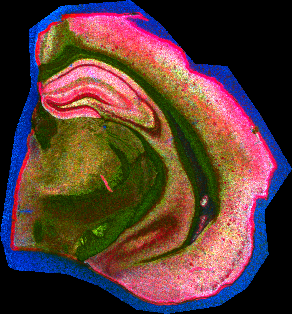

In [ ]:
display(Image.fromarray(pr))